# Plotting 3d and 2d surface files together with trajectory

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from plot_2D import plot_contour_trajectory

from scipy.interpolate import griddata

In [2]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import h5py
import argparse
import numpy as np
from os.path import exists
import seaborn as sns

In [3]:
surf_file = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/resnext6s8g_balancedTraining/18-06T02-15-09/surface_[-1.0,1.0,21]x[-1.0,1.0,21].h5'
dir_file = '/mnt/ssd2/Tassi/TassiMA/Voxceleb_original/exps/Res2NeXt6s8g_training_balanced/Traject/normed/directions_filter_normalized2.h5'
proj_file = '/mnt/ssd2/Tassi/TassiMA/Voxceleb_original/exps/Res2NeXt6s8g_training_balanced/Traject/normed/directions_filter_normalized2.h5_proj_cos.h5'

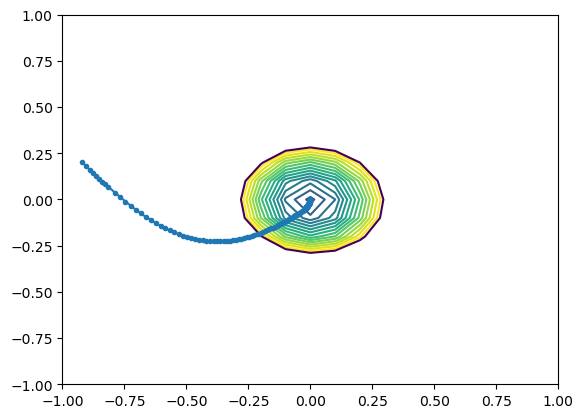

In [4]:
def plot_contour_trajectory_local(surf_file, dir_file, proj_file, surf_name='train_loss',
                            vmin=None, vmax=None, vlevel=0.5, show=False):
    """2D contour + trajectory"""

    assert exists(surf_file) and exists(proj_file) and exists(dir_file)

    # plot contours
    f = h5py.File(surf_file,'r')
    x = np.array(f['xcoordinates'][:])
    y = np.array(f['ycoordinates'][:])

    X, Y = np.meshgrid(x, y)
    if surf_name in f.keys():
        Z = np.array(f[surf_name][:])
    f.close()
    if vmin is None:
        vmin = np.min(Z)
    if vmax is None:
        vmax = np.max(Z)

    
    # figsize= (19.2,18)
    # figsize = (4.8,3.6)
    figsize = (5.5,4.5)
    labelsize = 18

    fig = plt.figure(figsize=figsize)
    
    ax = fig.add_subplot()
    # fig = plt.figure()
    CS1 = plt.contour(X, Y, Z, levels=np.arange(vmin, vmax, vlevel))
    # CS2 = plt.contour(X, Y, Z, levels=np.logspace(1, 8, num=8))
    plt.clabel(CS1, inline = True, fontsize=14, fmt='%d')

    # plot trajectories
    pf = h5py.File(proj_file, 'r')
    plt.plot(pf['proj_xcoord'][:], pf['proj_ycoord'][:], marker='.')

    # plot red points when learning rate decays
    # for e in [150, 225, 275]:
    #     plt.plot([pf['proj_xcoord'][e]], [pf['proj_ycoord'][e]], marker='.', color='r')

    # add PCA notes
    # df = h5py.File(dir_file,'r')
    # ratio_x = df['explained_variance_ratio_'][0]
    # ratio_y = df['explained_variance_ratio_'][1]
    # plt.xlabel('1st PC: %.2f %%' % (ratio_x*100), fontsize='xx-large')
    # plt.ylabel('2nd PC: %.2f %%' % (ratio_y*100), fontsize='xx-large')
    # df.close()
    # plt.clabel(CS1, inline=1, fontsize=6)
    # plt.clabel(CS2, inline=1, fontsize=6)
    # fig.savefig(proj_file + '_' + surf_name + '_2dcontour_proj.pdf', dpi=300,
    #             bbox_inches='tight', format='pdf')
    pf.close()
    tick_values = [-1,-0.5, 0,0.5, 1]
    ax.set_xticks(tick_values)
    ax.set_yticks(tick_values)
    ax.tick_params(axis='both', which='major', labelsize=labelsize)
    # if show: plt.show()
    plt.savefig('/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/trajectory_2d.pdf')

-0.9221, 0.2035
-0.9035, 0.1792
-0.8900, 0.1600
-0.8777, 0.1438
-0.8648, 0.1277
-0.8522, 0.1123
-0.8396, 0.0972
-0.8272, 0.0825
-0.8146, 0.0677
-0.7870, 0.0368
-0.7660, 0.0123
-0.7454, -0.0110
-0.7249, -0.0333
-0.7044, -0.0546
-0.6837, -0.0751
-0.6633, -0.0942
-0.6431, -0.1118
-0.6235, -0.1280
-0.6040, -0.1429
-0.5851, -0.1560
-0.5669, -0.1678
-0.5489, -0.1784
-0.5315, -0.1876
-0.5145, -0.1956
-0.4974, -0.2027
-0.4808, -0.2088
-0.4649, -0.2136
-0.4492, -0.2176
-0.4340, -0.2209
-0.4189, -0.2233
-0.4045, -0.2250
-0.3904, -0.2260
-0.3768, -0.2264
-0.3633, -0.2261
-0.3501, -0.2254
-0.3372, -0.2242
-0.3248, -0.2224
-0.3126, -0.2203
-0.3007, -0.2179
-0.2891, -0.2150
-0.2780, -0.2120
-0.2672, -0.2088
-0.2566, -0.2050
-0.2462, -0.2012
-0.2361, -0.1972
-0.2265, -0.1931
-0.2171, -0.1889
-0.2077, -0.1844
-0.1987, -0.1799
-0.1900, -0.1754
-0.1814, -0.1708
-0.1733, -0.1661
-0.1654, -0.1614
-0.1576, -0.1567
-0.1500, -0.1520
-0.1426, -0.1472
-0.1355, -0.1426
-0.1286, -0.1380
-0.1220, -0.1335
-0.1154,

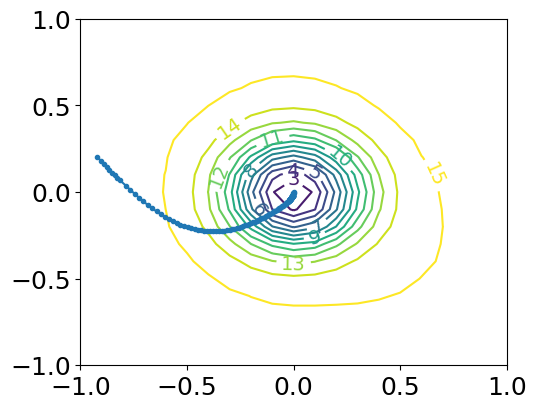

In [52]:
plot_contour_trajectory_local(surf_file, dir_file, proj_file, 'train_loss',show=True,vlevel=1)

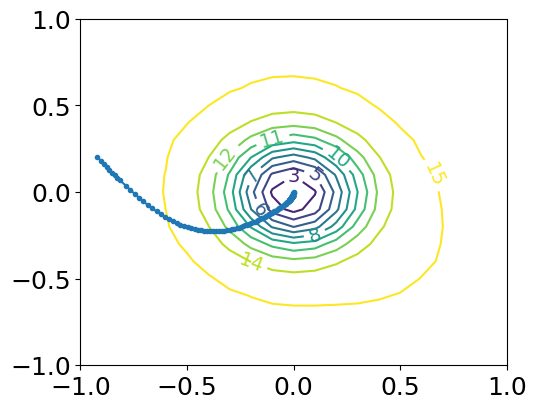

In [53]:
plot_contour_trajectory_local(surf_file, dir_file, proj_file, 'train_loss',show=True,vlevel=1.3)

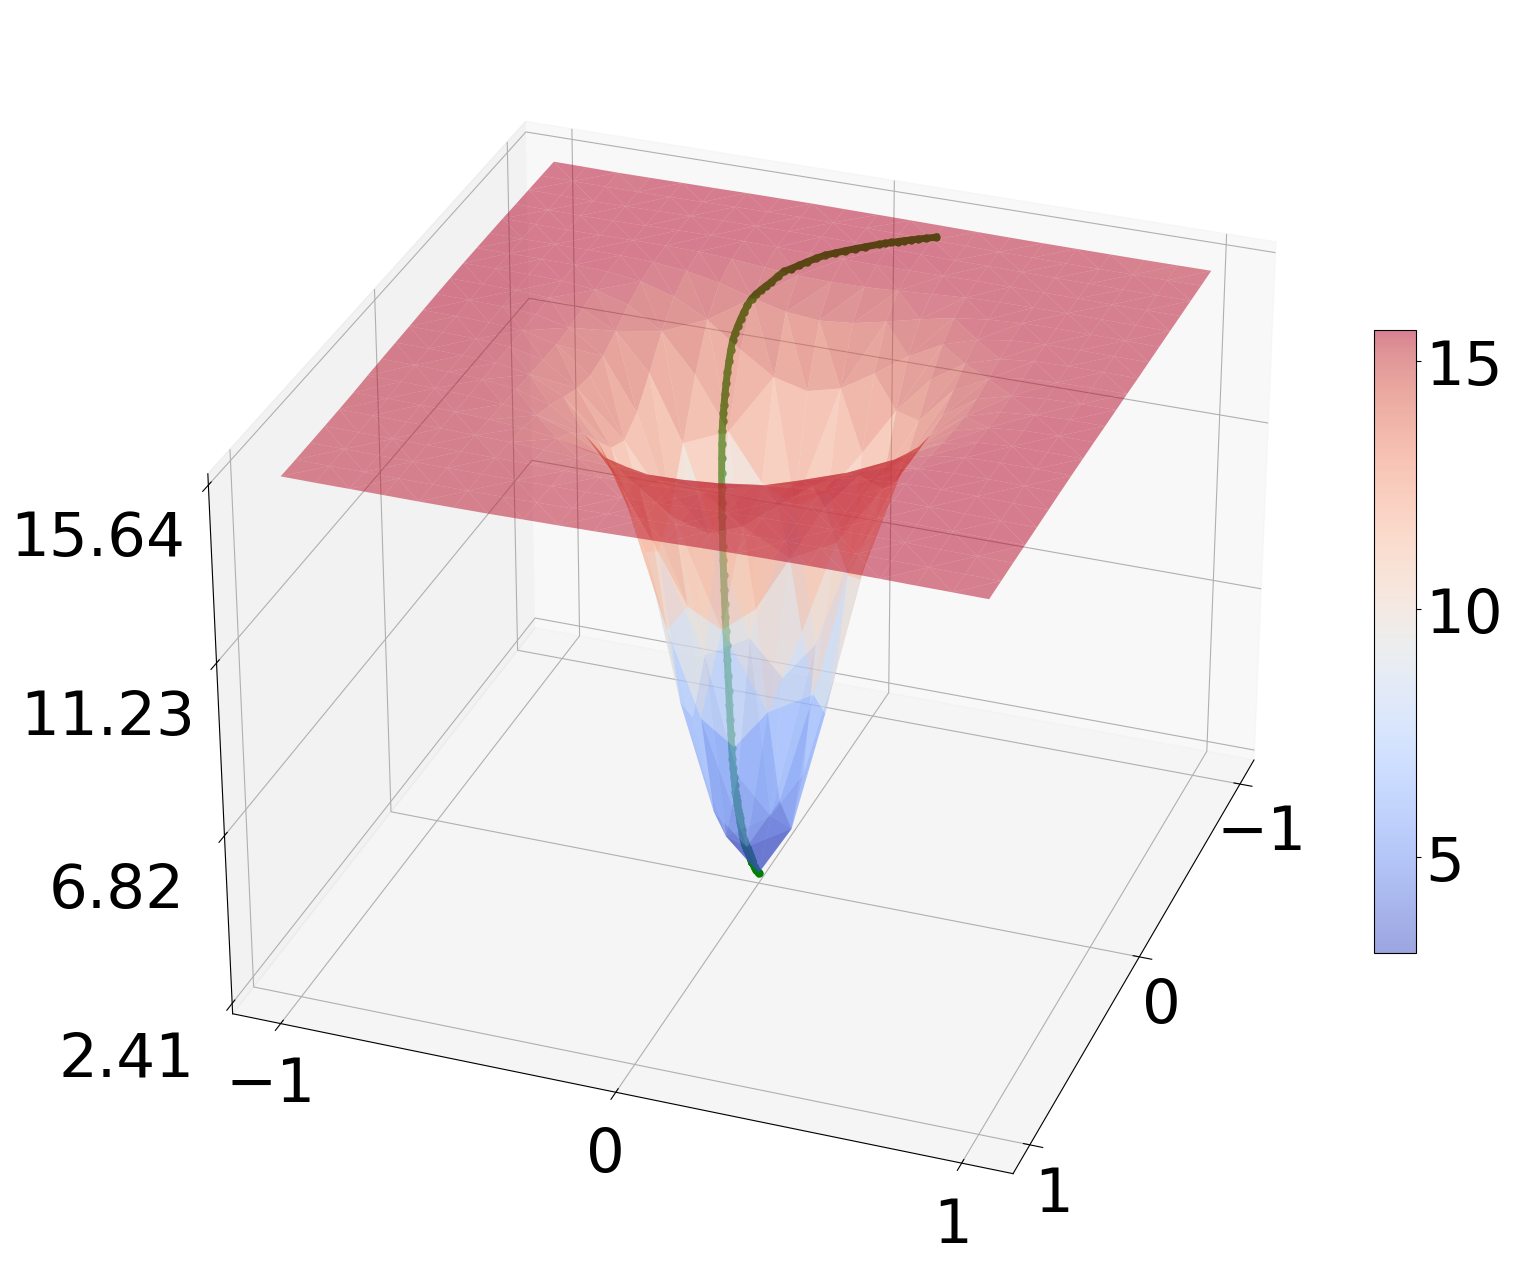

In [10]:
surf_name = 'train_loss'
surf_files = [surf_file]
save_path = '/mnt/ssd2/Tassi/TassiMA/loss-landscape/figures/trajectory_3d.pdf'

new_x = []
new_y = []
new_Z = []

for surf_file in surf_files:
    f = h5py.File(surf_file, 'r')
    x = np.array(f['xcoordinates'][:])
    y = np.array(f['ycoordinates'][:])
    Z = np.array(f[surf_name][:])
    X, Y = np.meshgrid(x, y)

    new_x += X.flatten().tolist()
    new_y += Y.flatten().tolist() 
    new_Z += Z.flatten().tolist() 
    f.close()

pf = h5py.File(proj_file, 'r')
X_path = pf['proj_xcoord'][:]
Y_path = pf['proj_ycoord'][:]
pf.close()

# Your original surface plot
figsize= (19.2,18)
labelsize = 44
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(projection='3d')
surf = ax.plot_trisurf(new_x, new_y, new_Z, linewidth=0.00, antialiased=True, cmap=cm.coolwarm, alpha=0.5)

# Assuming X and Y are your line's x and y coordinates
# Interpolate Z values for the X, Y coordinates based on the surface
Z_interp = griddata((new_x, new_y), new_Z, (X_path, Y_path), method='linear')

# Now plot the line with interpolated Z values
ax.plot(X_path, Y_path, Z_interp, color='g', marker='o', linestyle='-', linewidth=5, markersize=5)

cbar = fig.colorbar(surf, shrink=0.45, aspect=15,pad=0.00)
cbar.ax.tick_params(labelsize=labelsize)

# Set ticks on all axes
tick_values = [-1, 0, 1]
ax.set_xticks(tick_values)
ax.set_yticks(tick_values)
# Set dynamic Z-axis ticks
z_min, z_max = np.min(new_Z), np.max(new_Z)
z_ticks = np.linspace(z_min, z_max, 4)
ax.zaxis.set_tick_params(pad=38)
ax.xaxis.set_tick_params(pad=6)
ax.yaxis.set_tick_params(pad=8)
ax.set_zticks(z_ticks)
ax.tick_params(axis='both', which='major', labelsize=labelsize)

ax.view_init(elev=30, azim=20) #260 #20

# plt.show()

fig.savefig(save_path,bbox_inches='tight', format='pdf')



In [35]:

from matplotlib.animation import FuncAnimation